# Set up

In [1]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from calendar import month_name
from sdmetrics.single_column import RangeCoverage, KSComplement, CategoryCoverage, TVComplement
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import jensenshannon
from dython.nominal import associations
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

ModuleNotFoundError: No module named 'sdmetrics'

In [22]:
BASE_DIR = Path("")
LOCATION_GROUP = 3
CATEGORICAL_COLS = ["plugin_hour", "plugout_hour"]
NUMERICAL_COLS = ["connection_time", "energy_session"]
ALL_COLS = CATEGORICAL_COLS + NUMERICAL_COLS

# Helpers

In [23]:
# preprocessing real and fake data

def filter_invalid_sessions(df):
    valid = (df["connection_time"] > 0) & (df["energy_session"] > 0)
    valid = valid & (df["connection_time"] <= 120) & (df["energy_session"] <= 150)
    return df[valid].copy()


def add_time_features(df, plugin_time):
    df = df.copy()
    df["plugin_time"] = plugin_time
    df = df.dropna(subset=["plugin_time"])
    df["plugout_time"] = df["plugin_time"] + pd.to_timedelta(df["connection_time"], unit="h")

    df["plugin_hour"] = df["plugin_time"].dt.hour
    df["plugout_hour"] = df["plugout_time"].dt.hour
    df["month"] = df["plugin_time"].dt.month
    df["month_name"] = df["month"].map(lambda x: month_name[x])
    return df


def format_real_data(df):
    df = df.dropna(subset=["plugin_day", "plugin_month", "plugin_hour"]).copy()
    plugin_time = pd.to_datetime({
        "year": 2025,
        "month": df["plugin_month"],
        "day": df["plugin_day"],
        "hour": df["plugin_hour"],
    }, errors="coerce")
    return add_time_features(df, plugin_time)


def format_synthetic_data(df):
    df = df.dropna(subset=["__date__", "plugin_hour"]).copy()
    base_time = pd.to_datetime(df["__date__"]) + pd.to_timedelta(df["plugin_hour"], unit="h")
    perturb = pd.to_timedelta(np.random.randint(-30, 31, size=len(df)), unit="m")
    return add_time_features(df, base_time + perturb)


def load_synthetic_data(model_type):
    model_dir = BASE_DIR / model_type / "synthetic"
    data = {}
    for file in sorted(model_dir.glob("*.csv")):
        data[file.stem] = filter_invalid_sessions(pd.read_csv(file))
    return data


In [24]:
# evaluation metrics

def compute_distribution_metrics(real, synthetic, var_type):
    real = real.dropna()
    synthetic = synthetic.dropna()

    if len(real) == 0 or len(synthetic) == 0:
        return {m: np.nan for m in ["TVComplement", "JensenShannon", "KSComplement", "Wasserstein"]}

    if var_type == "categorical":
        real_probs = real.value_counts(normalize=True).sort_index()
        synth_probs = synthetic.value_counts(normalize=True).sort_index()
        all_cats = sorted(set(real_probs.index) | set(synth_probs.index))

        real_probs = real_probs.reindex(all_cats, fill_value=0)
        synth_probs = synth_probs.reindex(all_cats, fill_value=0)
        return {
            "TVComplement": TVComplement.compute(real, synthetic),
            "JensenShannon": jensenshannon(real_probs.values, synth_probs.values),
        }

    return {
        "KSComplement": KSComplement.compute(real, synthetic),
        "Wasserstein": wasserstein_distance(real, synthetic),
    }


def compute_coverage(real, synthetic, var_type):
    if var_type == "categorical":
        all_cats = sorted(set(real.dropna().unique()) | set(synthetic.dropna().unique()))
        real_cat = real.astype("category").cat.set_categories(all_cats)
        synth_cat = synthetic.astype("category").cat.set_categories(all_cats)
        return CategoryCoverage.compute(real_cat, synth_cat)
    return RangeCoverage.compute(real, synthetic)


def compute_correlation_similarity(real_df, synth_df):
    def get_association_matrix(df):
        df = df.copy()
        for col in CATEGORICAL_COLS:
            if col in df.columns:
                df[col] = df[col].astype("category")

        return associations(df[ALL_COLS], nominal_columns=CATEGORICAL_COLS,
                            numerical_columns=NUMERICAL_COLS, compute_only=True,
                            plot=False)["corr"]

    real_corr = get_association_matrix(real_df)
    synth_corr = get_association_matrix(synth_df)
    synth_corr = synth_corr.loc[real_corr.index, real_corr.columns]
    return np.linalg.norm(real_corr - synth_corr)


def calculate_model_score(metrics):
    weights = {
        "plugin_hour_TVComplement": 1/3,
        "connection_time_KSComplement": 1/3,
        "energy_session_KSComplement": 1/3,
    }

    score = 0
    for metric, weight in weights.items():
        score += metrics.get(metric, 0) * weight
    return score


In [25]:
def plot_panel_distribution_comparison(real_df, synth_df, columns, bins=30):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()
    metrics_report = []

    plt.rcParams.update({
        "axes.titlesize": 24,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 22,
    })

    for i, col in enumerate(columns):
        ax = axes[i]
        if col in CATEGORICAL_COLS:
            real_vals = real_df[col].value_counts(normalize=True).sort_index()
            synth_vals = synth_df[col].value_counts(normalize=True).sort_index()
            all_vals = sorted(set(real_vals.index) | set(synth_vals.index))

            real_vals = real_vals.reindex(all_vals, fill_value=0)
            synth_vals = synth_vals.reindex(all_vals, fill_value=0)
            tv = TVComplement.compute(real_df[col], synth_df[col])
            js = jensenshannon(real_vals.values, synth_vals.values)

            x = np.arange(len(all_vals))
            width = 0.35
            ax.bar(x - width/2, real_vals.values, width, alpha=0.7, label="Real", color="#1f77b4")
            ax.bar(x + width/2, synth_vals.values, width, alpha=0.7, label="Synthetic", color="#ff7f0e")
            ax.set_xticks(x)
            ax.set_xticklabels(all_vals, fontsize=16)
            ax.set_ylabel("Proportion")
            metrics_report.append(f"{col}: TVComplement={tv:.3f} | JSD={js:.3f}")
        else:
            ks = KSComplement.compute(real_df[col], synth_df[col])
            wd = wasserstein_distance(real_df[col], synth_df[col])

            ax.hist(real_df[col], bins=bins, alpha=0.5, label="Real", density=True, color="#1f77b4")
            ax.hist(synth_df[col], bins=bins, alpha=0.5, label="Synthetic", density=True, color="#ff7f0e")
            ax.set_ylabel("Density")
            metrics_report.append(f"{col}: KSComplement={ks:.3f} | Wasserstein={wd:.3f}")

        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_title(f"{col.replace('_', ' ').title()} Distribution")

    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2,
               bbox_to_anchor=(0.5, 1.02), fontsize=20, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



In [26]:
def evaluate_model(real_df, synth_df):
    synth_data = format_synthetic_data(synth_df)
    results = {"yearly_metrics": {}, "monthly_metrics": {}}

    yearly_metrics = {}
    for col in ALL_COLS:
        col_type = "categorical" if col in CATEGORICAL_COLS else "numerical"
        dist_metrics = compute_distribution_metrics(real_df[col], synth_data[col], col_type)
        for metric, value in dist_metrics.items():
            yearly_metrics[f"{col}_{metric}"] = value
        yearly_metrics[f"{col}_Coverage"] = compute_coverage(real_df[col], synth_data[col], col_type)

    yearly_metrics["CorrelationSimilarity"] = compute_correlation_similarity(real_df, synth_data)
    results["yearly_metrics"] = yearly_metrics

    for month in range(1, 13):
        month_label = month_name[month]
        month_real = real_df[real_df["month"] == month]
        month_synth = synth_data[synth_data["month"] == month]
        if month_real.empty or month_synth.empty:
            continue

        month_metrics = {}
        for col in ALL_COLS:
            col_type = "categorical" if col in CATEGORICAL_COLS else "numerical"
            dist_metrics = compute_distribution_metrics(month_real[col], month_synth[col], col_type)
            for metric, value in dist_metrics.items():
                month_metrics[f"{col}_{metric}"] = value
            month_metrics[f"{col}_Coverage"] = compute_coverage(month_real[col], month_synth[col], col_type)

        month_metrics["CorrelationSimilarity"] = compute_correlation_similarity(month_real, month_synth)
        results["monthly_metrics"][month_label] = month_metrics

    return results


def create_metrics_table(results):
    yearly_metrics = results["yearly_metrics"].copy()
    yearly_metrics["period"] = "Year"
    yearly_metrics["composite_score"] = calculate_model_score(results["yearly_metrics"])

    monthly_rows = []
    for month, metrics in results["monthly_metrics"].items():
        row = metrics.copy()
        row["period"] = month
        row["composite_score"] = calculate_model_score(metrics)
        monthly_rows.append(row)

    metrics_df = pd.DataFrame([yearly_metrics] + monthly_rows)
    columns_order = ["period", "composite_score"] + [
        col for col in metrics_df.columns if col not in ["period", "composite_score"]
    ]
    return metrics_df[columns_order]


# Evaluation

In [27]:
VAL_PATH = BASE_DIR / "CTGAN/sets/val.csv"
TEST_PATH = BASE_DIR / "CTGAN/sets/test.csv"
TRAIN_PATH = BASE_DIR / "CTGAN/sets/train.csv"

val_df = pd.read_csv(VAL_PATH).drop(columns="strata", errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns="strata", errors="ignore")
train_df = pd.read_csv(TRAIN_PATH).drop(columns="strata", errors="ignore")

val_lg3 = filter_invalid_sessions(val_df[val_df["location_group"] == LOCATION_GROUP])
val_lg3 = format_real_data(val_lg3)

test_lg3 = filter_invalid_sessions(test_df[test_df["location_group"] == LOCATION_GROUP])
test_lg3 = format_real_data(test_lg3)

synthetic_models = {"CTGAN": load_synthetic_data("CTGAN")}

combined_lg3 = pd.concat([val_lg3, test_lg3], ignore_index=True)

# test_lg3 = combined_lg3.copy()

In [28]:
synthetic_models['CTGAN']['synthetic_year_3_20250616214332'] = synthetic_models['CTGAN']['synthetic_year_3_20250616214332'].rename({'date': '__date__'}, axis='columns')

In [29]:
synthetic_models

{'CTGAN': {'synthetic_year_3_20250616214332':       location_group weekday_group  plugin_hour  plugin_day  plugin_month  \
  0                3.0        Mon-Th            0          27             5   
  1                3.0        Mon-Th           19           3             5   
  2                3.0        Mon-Th           10           9             6   
  3                3.0        Mon-Th           22          26            10   
  4                3.0        Mon-Th           22          27             9   
  ...              ...           ...          ...         ...           ...   
  4749             3.0        Sunday           20          15             3   
  4750             3.0        Sunday           18          18             2   
  4751             3.0        Sunday           21           1             1   
  4752             3.0        Sunday           13          19             1   
  4753             3.0        Sunday            2          18             1   
  
     

In [30]:
val_results = []
for model_type, models in synthetic_models.items():
    for model_name, synth_df in models.items():
        if model_name == "synthetic_year_3_20250616214332": 
            continue
        
        if "d3" in model_name:
            continue

        model_results = evaluate_model(val_lg3, synth_df)
        
        yearly_score = calculate_model_score(model_results["yearly_metrics"])
        monthly_scores = [calculate_model_score(m) for m in model_results["monthly_metrics"].values()]
        monthly_avg = np.mean(monthly_scores) if monthly_scores else 0
        overall_score = (yearly_score + monthly_avg) / 2
        
        val_results.append({
            "model": model_type,
            "model_id": model_name,
            "yearly_score": yearly_score,
            "monthly_avg_score": monthly_avg,
            "overall_score": overall_score,
            **{f"yearly_{k}": v for k, v in model_results["yearly_metrics"].items()},
            **{f"monthly_avg_{k}": np.mean([m.get(k, np.nan) for m in model_results["monthly_metrics"].values()]) 
               for k in model_results["yearly_metrics"].keys()}
        })

val_results_df = pd.DataFrame(val_results)
best_val_model = val_results_df.loc[val_results_df["overall_score"].idxmax()]
print(f"\nBest Validation Model: {best_val_model['model']} - {best_val_model['model_id']}")
print(f"Overall Score: {best_val_model['overall_score']:.4f}")


Best Validation Model: CTGAN - synthetic_year_3_d2_8h
Overall Score: 0.8401


In [31]:
val_results_df

,model,model_id,yearly_score,monthly_avg_score,overall_score,yearly_plugin_hour_TVComplement,yearly_plugin_hour_JensenShannon,yearly_plugin_hour_Coverage,yearly_plugout_hour_TVComplement,yearly_plugout_hour_JensenShannon,...,monthly_avg_plugout_hour_TVComplement,monthly_avg_plugout_hour_JensenShannon,monthly_avg_plugout_hour_Coverage,monthly_avg_connection_time_KSComplement,monthly_avg_connection_time_Wasserstein,monthly_avg_connection_time_Coverage,monthly_avg_energy_session_KSComplement,monthly_avg_energy_session_Wasserstein,monthly_avg_energy_session_Coverage,monthly_avg_CorrelationSimilarity
0,CTGAN,synthetic_year_3_d1_2h,0.879730,0.775075,0.827402,0.833506,0.144688,1.0,0.696879,0.285190,...,0.590860,0.398082,1.0,0.810143,3.550130,0.981815,0.840771,3.166552,0.977940,0.934523
1,CTGAN,synthetic_year_3_d1_4h,0.869991,0.768196,0.819094,0.823457,0.155525,1.0,0.681849,0.298107,...,0.570894,0.409891,1.0,0.843791,2.959573,0.965514,0.801712,3.323863,0.946331,0.957668
2,CTGAN,synthetic_year_3_d1_8h,0.838347,0.761907,0.800127,0.815851,0.147621,1.0,0.717689,0.275444,...,0.594341,0.393935,1.0,0.830295,3.063504,0.991092,0.789408,3.896229,0.897328,0.968223
3,CTGAN,synthetic_year_3_d1_off,0.875136,0.779056,0.827096,0.829093,0.150645,1.0,0.681654,0.296946,...,0.563977,0.415793,1.0,0.839637,2.719218,0.991927,0.825910,2.805602,0.968897,0.951253
4,CTGAN,synthetic_year_3_d2_2h,0.845611,0.752900,0.799256,0.812704,0.156179,1.0,0.661427,0.317407,...,0.560366,0.420256,1.0,0.779929,3.819491,0.979503,0.817614,3.225990,0.949995,0.922142
5,CTGAN,synthetic_year_3_d2_4h,0.868540,0.754346,0.811443,0.861484,0.139168,1.0,0.735689,0.263933,...,0.610602,0.384013,1.0,0.794144,6.346804,0.999062,0.811290,2.846111,0.969407,0.950577
6,CTGAN,synthetic_year_3_d2_8h,0.892709,0.787441,0.840075,0.845780,0.135327,1.0,0.690311,0.296113,...,0.578158,0.404996,1.0,0.841213,3.775374,0.990669,0.833305,2.758609,0.976100,0.934021
7,CTGAN,synthetic_year_3_d2_off,0.847079,0.750861,0.798970,0.877407,0.120227,1.0,0.710100,0.289276,...,0.602244,0.395898,1.0,0.779654,4.928758,0.986016,0.778253,4.325334,0.983696,0.956123
8,CTGAN,synthetic_year_3_d4_2h,0.824954,0.738533,0.781744,0.786601,0.172987,1.0,0.692134,0.293381,...,0.591832,0.398788,1.0,0.778319,4.546925,0.980776,0.794572,4.451956,0.992359,0.977479
9,CTGAN,synthetic_year_3_d4_4h,0.840108,0.740471,0.790290,0.759842,0.198185,1.0,0.678126,0.312008,...,0.550118,0.423689,1.0,0.785525,4.249712,0.943167,0.837484,2.774805,0.977421,0.951992


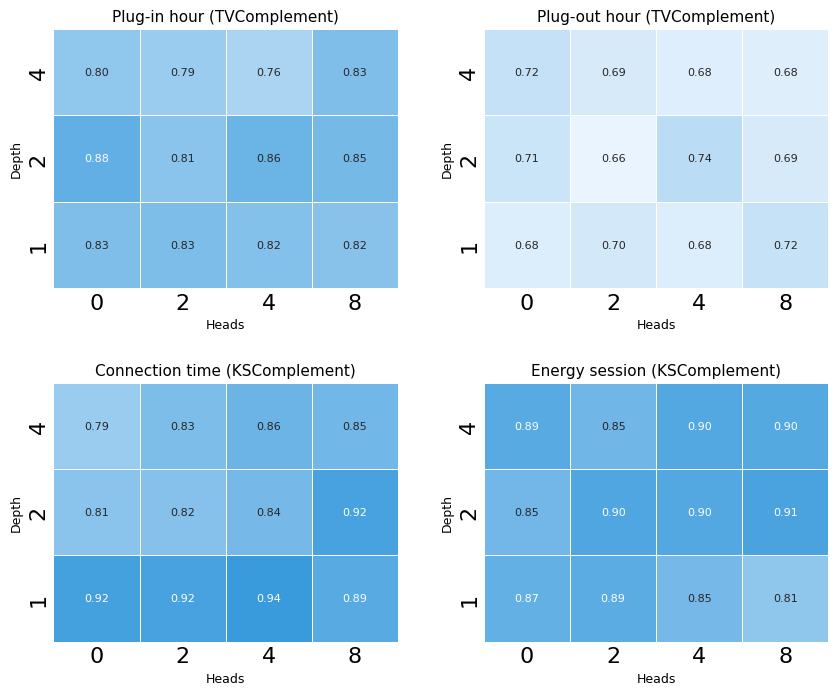

In [32]:
val_results_df['Heads'] = (
    val_results_df['model_id']
    .str.extract(r'_(\d+)h$')[0]
    .fillna('0')
    .astype(int)
)
val_results_df['Depth'] = val_results_df['model_id'].str.extract(r'_d(\d)')[0].astype(int)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid': False
})

cmap = LinearSegmentedColormap.from_list('minimal_blue', ['#f0f7ff', '#3498db'], N=256)

metrics = [
    ('yearly_plugin_hour_TVComplement', 'Plug-in hour (TVComplement)'),
    ('yearly_plugout_hour_TVComplement', 'Plug-out hour (TVComplement)'),
    ('yearly_connection_time_KSComplement', 'Connection time (KSComplement)'),
    ('yearly_energy_session_KSComplement', 'Energy session (KSComplement)')
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (metric, title) in zip(axes.flat, metrics):
    heatmap_data = (
        val_results_df.pivot_table(
            index='Depth',
            columns='Heads',
            values=metric,
            aggfunc='first'
        ).sort_index(ascending=False)
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 8},
        ax=ax,
        vmin=0.65,
        vmax=0.95
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Heads', fontsize=9)
    ax.set_ylabel('Depth', fontsize=9)
    ax.tick_params(axis='both', which='both', length=0)

fig.subplots_adjust(wspace=0.25, hspace=0.35)
plt.savefig('ctgan_validation_grid_heatmaps.png', dpi=300)
plt.show()


In [33]:
heatmap_data = (
        val_results_df.pivot_table(
            index='Depth',
            columns='Heads',
            values='yearly_plugin_hour_TVComplement',
            aggfunc='first'
        ).sort_index(ascending=False)
    )

heatmap_data

Heads,0,2,4,8
Depth,,,,
4,0.803385,0.786601,0.759842,0.829072
2,0.877407,0.812704,0.861484,0.845780
1,0.829093,0.833506,0.823457,0.815851


In [34]:
synth_2025 = synthetic_models["CTGAN"]["synthetic_year_3_d2_8h"]
test_results = evaluate_model(test_lg3, synth_2025)

yearly_score = calculate_model_score(test_results["yearly_metrics"])
monthly_scores = [calculate_model_score(m) for m in test_results["monthly_metrics"].values()]
monthly_avg = np.mean(monthly_scores) if monthly_scores else 0
overall_score = (yearly_score + monthly_avg) / 2

monthly_scores = {month: calculate_model_score(metrics) 
                  for month, metrics in test_results["monthly_metrics"].items()}
best_month = max(monthly_scores, key=monthly_scores.get)
worst_month = min(monthly_scores, key=monthly_scores.get)

print(f"\nTest Set Performance for synthetic_2025:")
print(f"Yearly Score: {yearly_score:.4f}")
print(f"Average Monthly Score: {monthly_avg:.4f}")
print(f"Best Month: {best_month} ({monthly_scores[best_month]:.4f})")
print(f"Worst Month: {worst_month} ({monthly_scores[worst_month]:.4f})")


Test Set Performance for synthetic_2025:
Yearly Score: 0.8895
Average Monthly Score: 0.7782
Best Month: December (0.8277)
Worst Month: April (0.6960)



Yearly Distributions Comparison (Test Set):


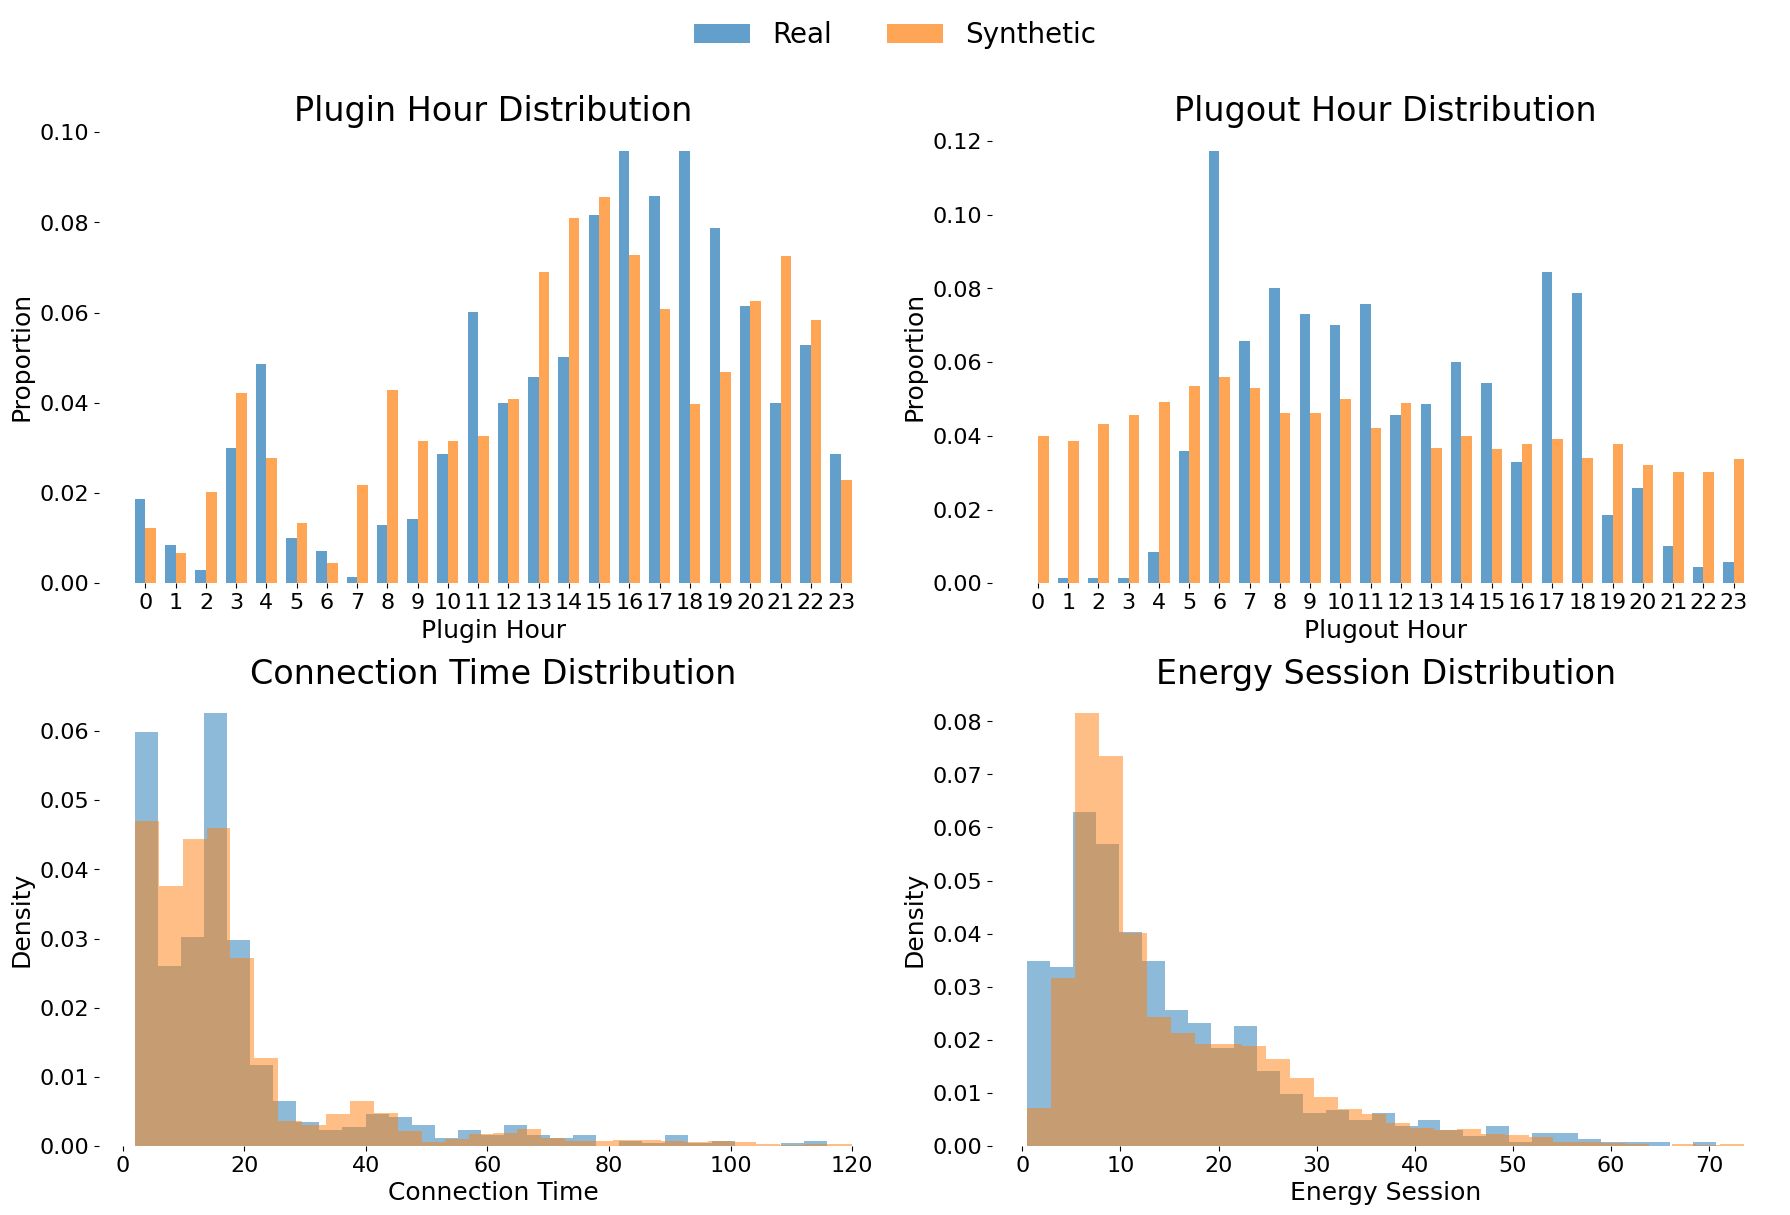


December Distributions (Best Month):


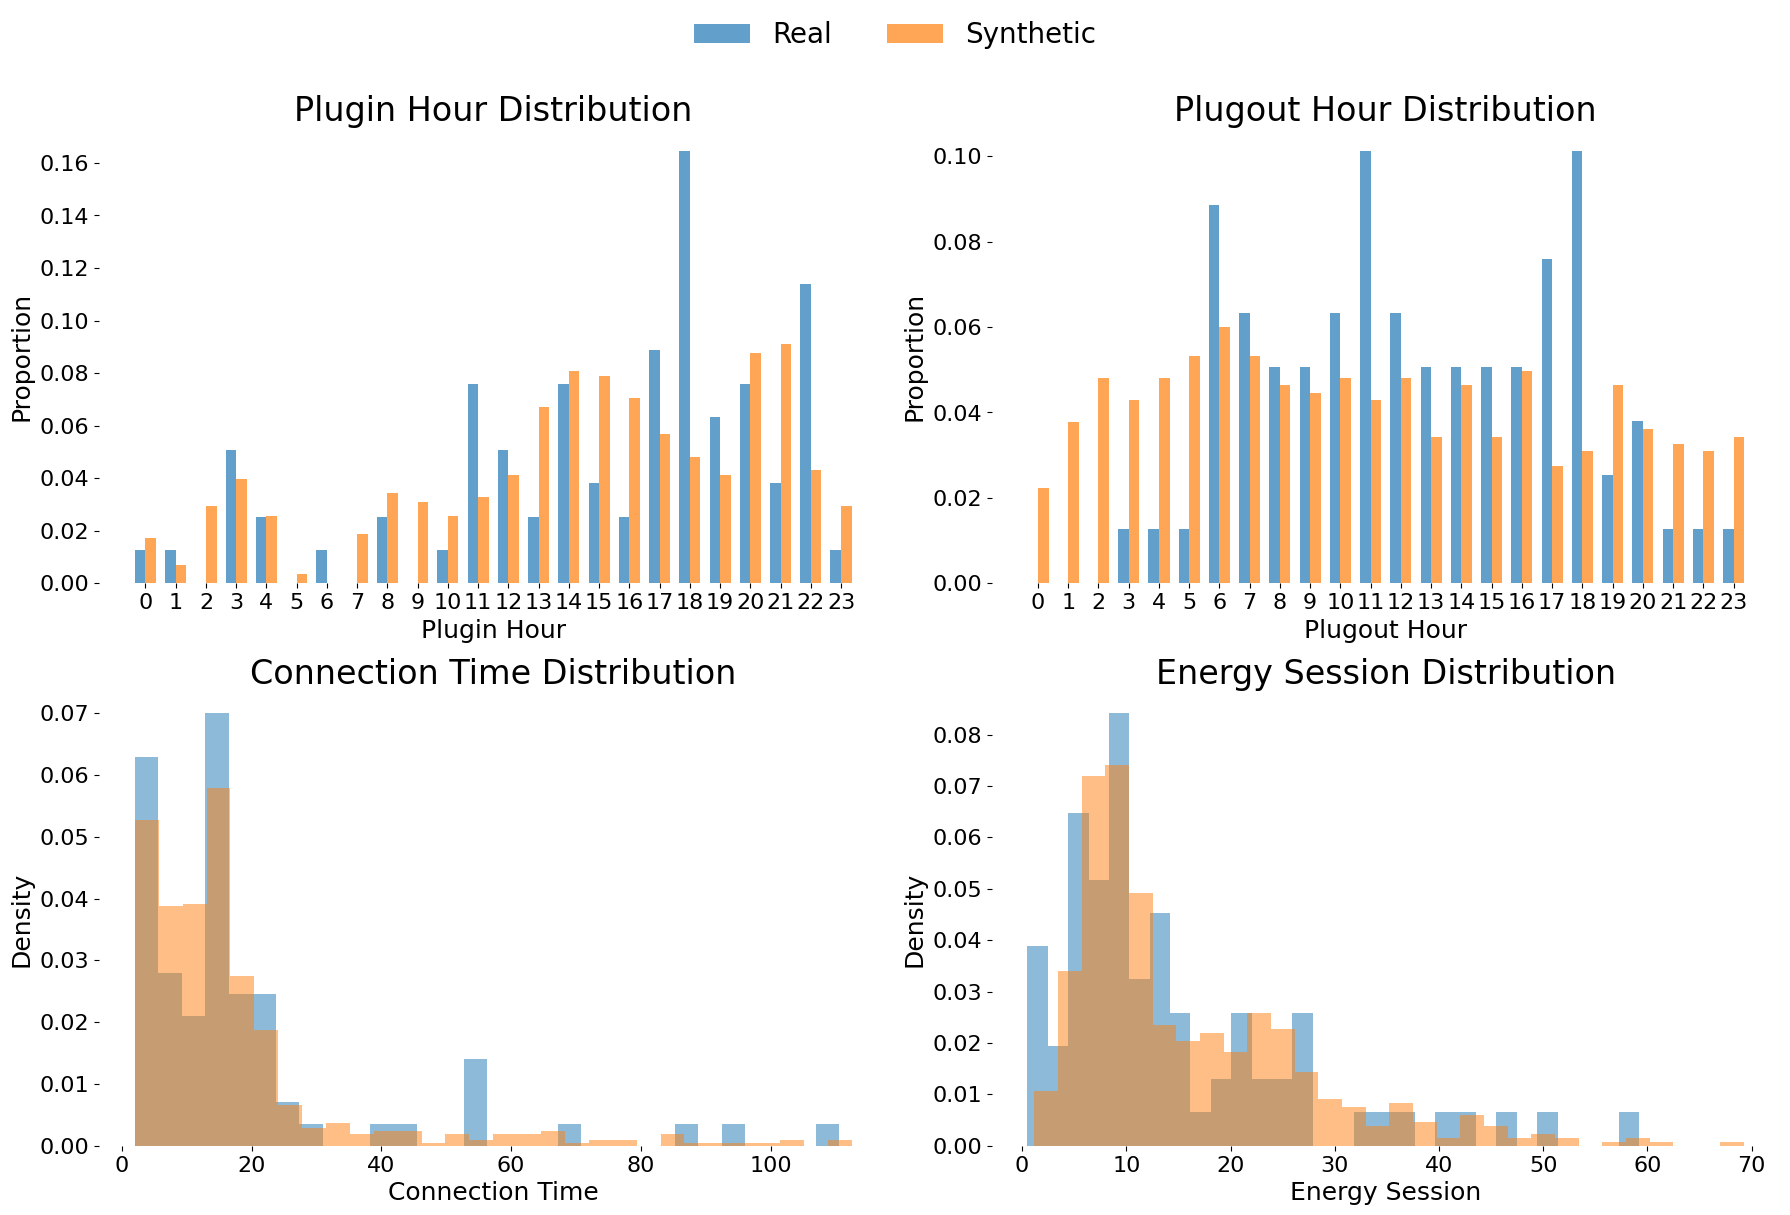


April Distributions (Worst Month):


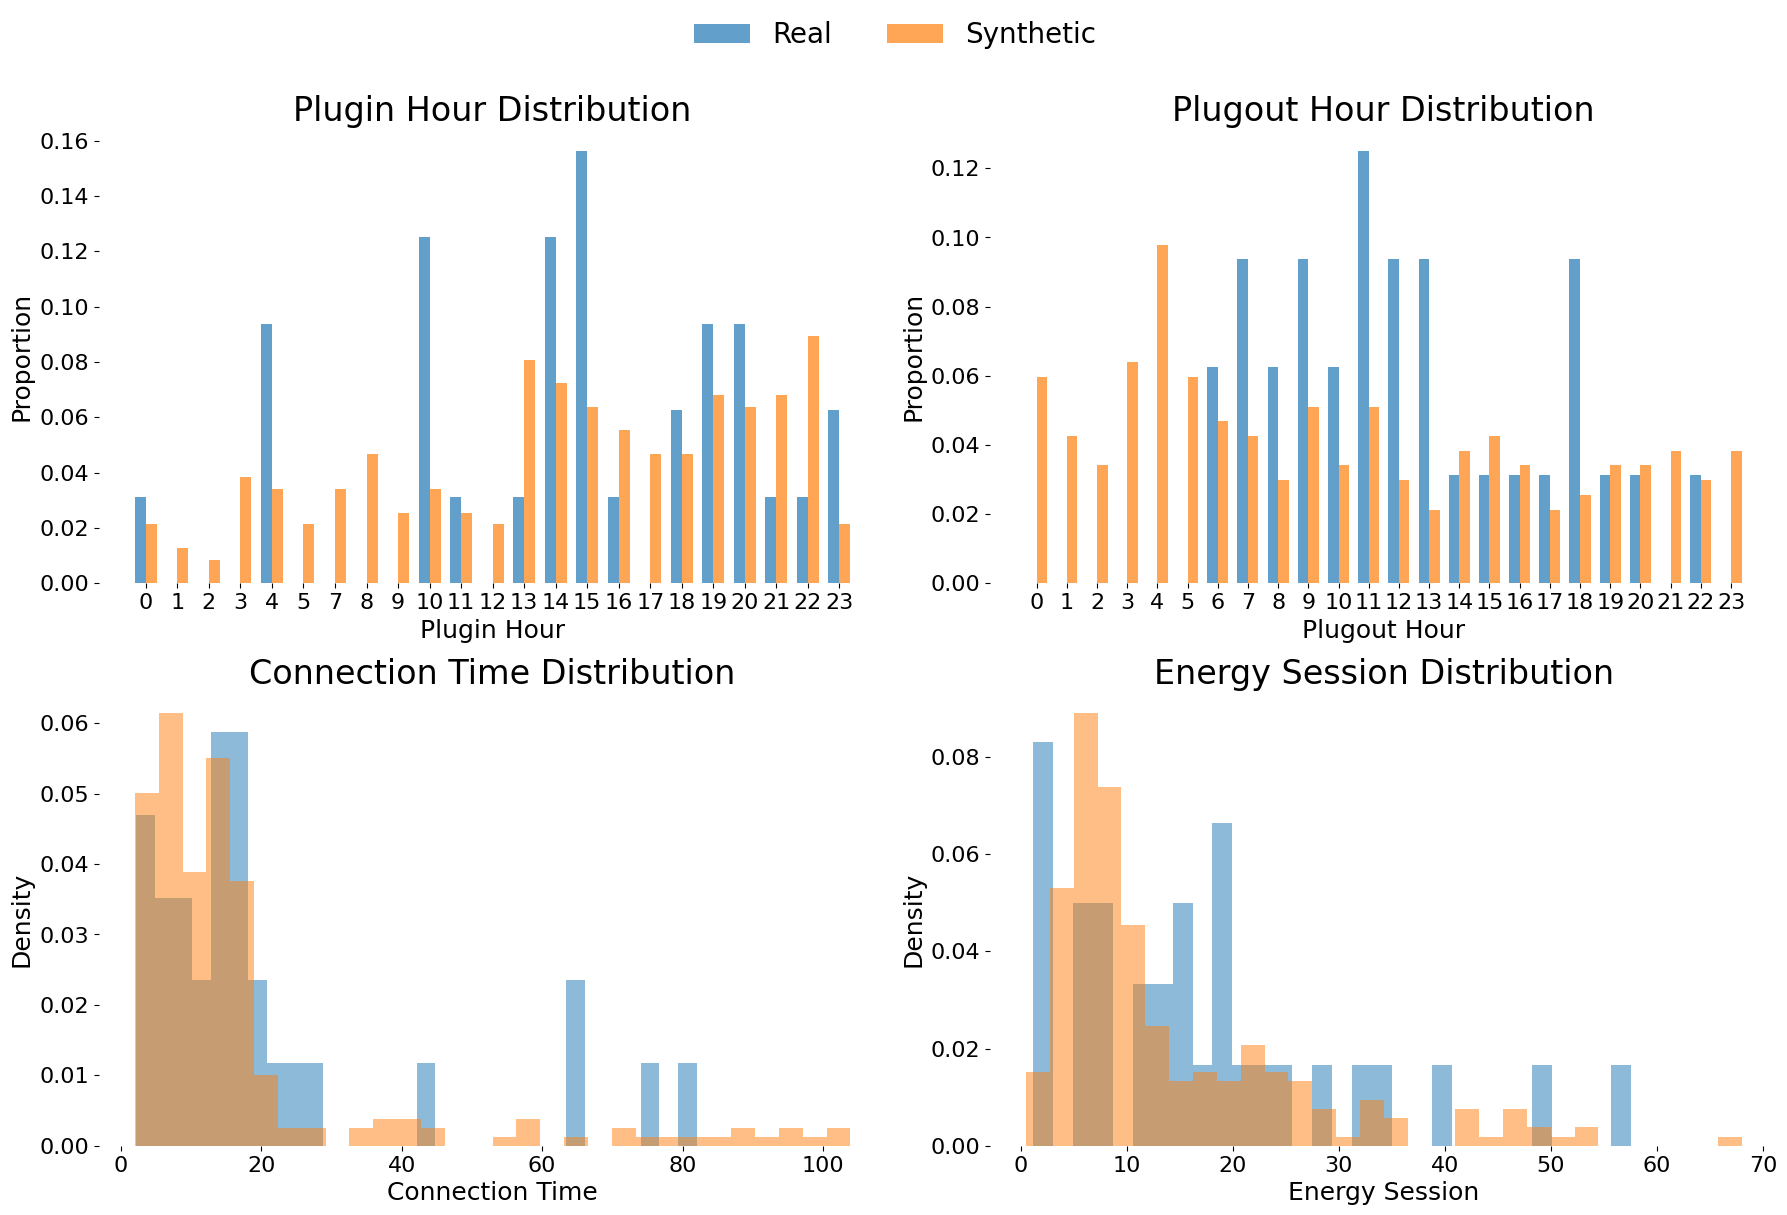

In [35]:
synth_2025_formatted = format_synthetic_data(synth_2025)

print("\nYearly Distributions Comparison (Test Set):")
plot_panel_distribution_comparison(
    test_lg3, 
    synth_2025_formatted,
    columns=ALL_COLS
)

print(f"\n{best_month} Distributions (Best Month):")
plot_panel_distribution_comparison(
    test_lg3[test_lg3["month_name"] == best_month],
    synth_2025_formatted[synth_2025_formatted["month_name"] == best_month],
    columns=ALL_COLS)

print(f"\n{worst_month} Distributions (Worst Month):")
plot_panel_distribution_comparison(
    test_lg3[test_lg3["month_name"] == worst_month],
    synth_2025_formatted[synth_2025_formatted["month_name"] == worst_month],
    columns=ALL_COLS)

val_results_df.to_csv(BASE_DIR / "validation_results.csv", index=False)

test_results_df = pd.DataFrame([{
    "model": "CTGAN",
    "model_id": "synthetic_2025",
    "yearly_score": yearly_score,
    "monthly_avg_score": monthly_avg,
    "overall_score": overall_score,
    **{f"yearly_{k}": v for k, v in test_results["yearly_metrics"].items()},
    **{f"monthly_avg_{k}": np.mean([m.get(k, np.nan) for m in test_results["monthly_metrics"].values()]) 
       for k in test_results["yearly_metrics"].keys()}
}])
test_results_df.to_csv(BASE_DIR / "test_results_synthetic_2025.csv", index=False)

In [36]:
test_metrics_table = create_metrics_table(test_results)

formatted_table = test_metrics_table.copy()

for col in formatted_table.columns:
    if col in ["period", "composite_score"]:
        continue

    if "Coverage" in col:
        formatted_table[col] = formatted_table[col].apply(lambda x: f"{x:.0%}")
    elif "JensenShannon" in col or "Wasserstein" in col or "CorrelationSimilarity" in col:
        formatted_table[col] = formatted_table[col].apply(lambda x: f"{x:.3f}")
    else:
        formatted_table[col] = formatted_table[col].apply(lambda x: f"{x:.4f}")

formatted_table["composite_score"] = formatted_table["composite_score"].apply(lambda x: f"{x:.4f}")

print("Performance Metrics for synthetic_2025 Model on Test Set")
display(formatted_table)

test_metrics_table.to_csv(BASE_DIR / "detailed_metrics_synthetic_2025.csv", index=False)
print("\nDetailed metrics saved to 'detailed_metrics_synthetic_2025.csv'")

Performance Metrics for synthetic_2025 Model on Test Set


,period,composite_score,plugin_hour_TVComplement,plugin_hour_JensenShannon,plugin_hour_Coverage,plugout_hour_TVComplement,plugout_hour_JensenShannon,plugout_hour_Coverage,connection_time_KSComplement,connection_time_Wasserstein,connection_time_Coverage,energy_session_KSComplement,energy_session_Wasserstein,energy_session_Coverage,CorrelationSimilarity
0,Year,0.8895,0.8022,0.189,100%,0.6785,0.312,100%,0.9492,0.692,100%,0.9171,0.931,100%,0.449
1,January,0.8264,0.7129,0.259,100%,0.6065,0.373,100%,0.8781,2.125,90%,0.8883,1.607,99%,0.484
2,February,0.8036,0.6942,0.319,100%,0.6125,0.388,100%,0.8373,3.184,100%,0.8792,1.976,83%,0.405
3,March,0.8177,0.6808,0.313,100%,0.6326,0.367,100%,0.8753,2.482,100%,0.8971,2.106,100%,0.953
4,April,0.6960,0.5888,0.383,100%,0.5335,0.456,100%,0.7424,5.146,100%,0.7566,3.692,100%,1.162
5,May,0.7377,0.5662,0.429,100%,0.3820,0.550,100%,0.8592,4.090,100%,0.7878,2.969,100%,1.526
6,June,0.7329,0.5905,0.425,100%,0.5608,0.439,100%,0.7746,6.878,100%,0.8337,2.898,100%,1.309
7,July,0.7474,0.7028,0.312,100%,0.5583,0.432,100%,0.8452,2.372,100%,0.6940,4.969,94%,1.478
8,August,0.7523,0.5540,0.426,100%,0.5437,0.441,100%,0.8477,3.535,100%,0.8553,2.868,99%,0.793
9,September,0.7652,0.5938,0.376,100%,0.5337,0.452,100%,0.8327,5.870,100%,0.8692,2.064,100%,1.430



Detailed metrics saved to 'detailed_metrics_synthetic_2025.csv'


In [37]:
summary_cols = [
    "period",
    "composite_score",
    "plugin_hour_TVComplement",
    "plugin_hour_JensenShannon",
    "connection_time_KSComplement",
    "connection_time_Wasserstein",
    "energy_session_KSComplement",
    "energy_session_Wasserstein",
    "CorrelationSimilarity",
]

summary_table = test_metrics_table[summary_cols].copy()
summary_table_formatted = summary_table.copy()

for col in summary_table_formatted.columns[1:]:
    if "JensenShannon" in col or "Wasserstein" in col or "CorrelationSimilarity" in col:
        summary_table_formatted[col] = summary_table_formatted[col].apply(lambda x: f"{x:.3f}")
    else:
        summary_table_formatted[col] = summary_table_formatted[col].apply(lambda x: f"{x:.4f}")

print("Key Performance Metrics for synthetic_2025 Model")
display(summary_table_formatted)

summary_table.to_csv(BASE_DIR / "summary_metrics_synthetic_2025.csv", index=False)

Key Performance Metrics for synthetic_2025 Model


,period,composite_score,plugin_hour_TVComplement,plugin_hour_JensenShannon,connection_time_KSComplement,connection_time_Wasserstein,energy_session_KSComplement,energy_session_Wasserstein,CorrelationSimilarity
0,Year,0.8895,0.8022,0.189,0.9492,0.692,0.9171,0.931,0.449
1,January,0.8264,0.7129,0.259,0.8781,2.125,0.8883,1.607,0.484
2,February,0.8036,0.6942,0.319,0.8373,3.184,0.8792,1.976,0.405
3,March,0.8177,0.6808,0.313,0.8753,2.482,0.8971,2.106,0.953
4,April,0.6960,0.5888,0.383,0.7424,5.146,0.7566,3.692,1.162
5,May,0.7377,0.5662,0.429,0.8592,4.090,0.7878,2.969,1.526
6,June,0.7329,0.5905,0.425,0.7746,6.878,0.8337,2.898,1.309
7,July,0.7474,0.7028,0.312,0.8452,2.372,0.6940,4.969,1.478
8,August,0.7523,0.5540,0.426,0.8477,3.535,0.8553,2.868,0.793
9,September,0.7652,0.5938,0.376,0.8327,5.870,0.8692,2.064,1.430


/var/folders/yr/fk6c3f455rdf97sxlv2n6dtm0000gn/T/ipykernel_80235/946887810.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


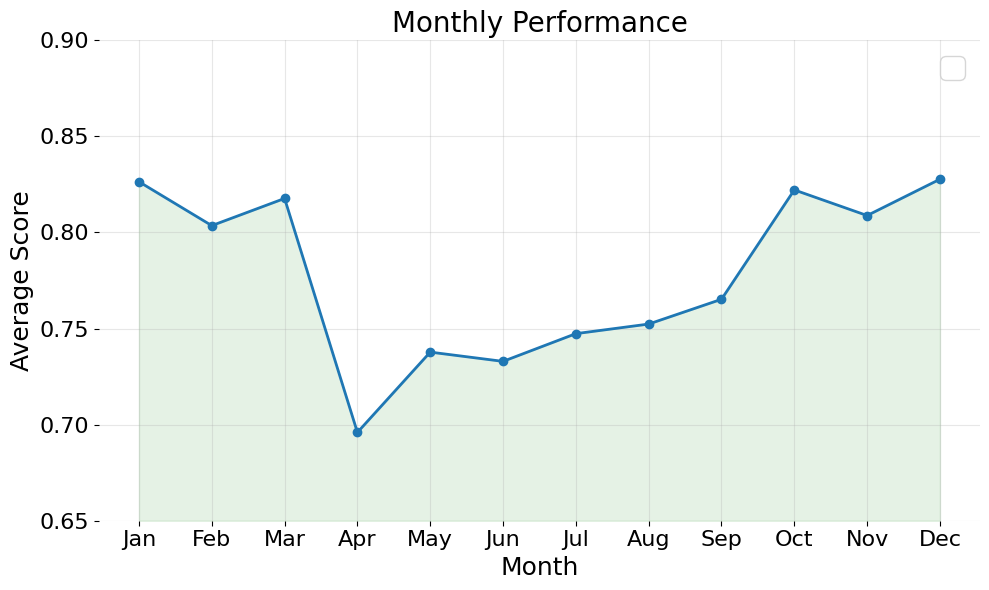

In [38]:
plt.figure(figsize=(10, 6))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
scores = summary_table['composite_score'][1:13]

plt.plot(months, scores, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
plt.fill_between(months, scores, 0.65, alpha=0.1, color='green')
plt.xlabel('Month', fontsize=18)
plt.ylabel('Average Score', fontsize=18)
plt.title('Monthly Performance', fontsize=20)
plt.ylim(0.65, 0.9)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

In [39]:
counts_month = train_df[train_df['location_group'] == 3].groupby("plugin_month").count()['location_group']/3264

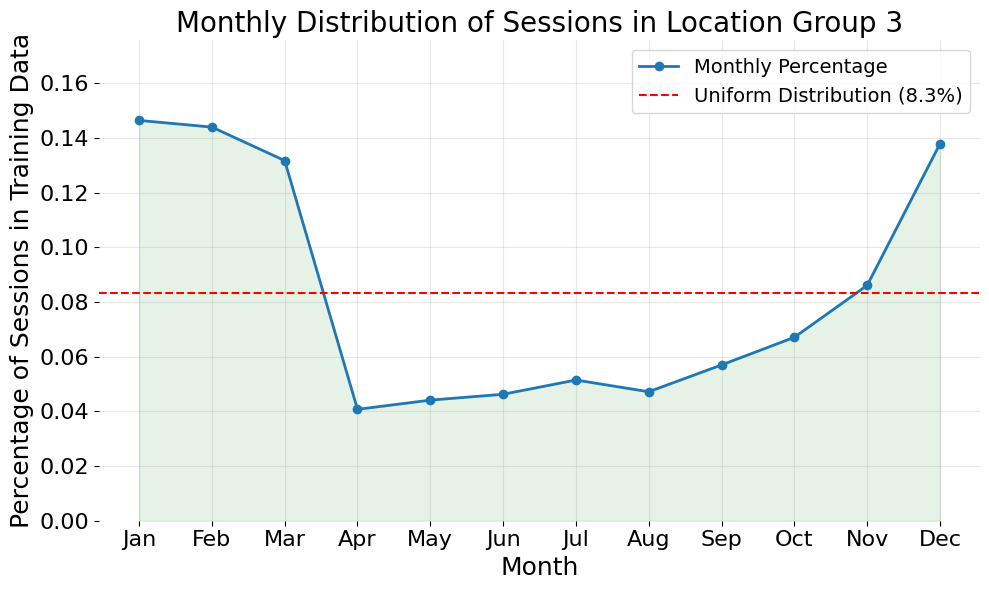

In [40]:
plt.figure(figsize=(10, 6))

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
scores = counts_month

plt.plot(months, scores, marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Monthly Percentage')
plt.axhline(y=1/12, color='r', linestyle='--', label='Uniform Distribution (8.3%)')
plt.fill_between(months, scores, 0, alpha=0.1, color='green')

plt.xlabel('Month', fontsize=18)
plt.ylabel('Percentage of Sessions in Training Data', fontsize=18)
plt.title('Monthly Distribution of Sessions in Location Group 3', fontsize=20)
plt.ylim(0.0, max(scores) * 1.2)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()